In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import GComputation  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(0)
n = 4000
df = pd.DataFrame({
    "age": rng.integers(20, 75, n),
    "female": rng.binomial(1, 0.52, n),
    "treated": rng.binomial(1, 0.40, n),
})
lp = -1.5 + 0.04 * df["age"] - 0.3 * df["female"] + 0.8 * df["treated"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

In [2]:
fit = smf.glm(
    "y ~ age + female + treated",
    data=df,
    family=sm.families.Binomial(),
).fit()
print(fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4000
Model:                            GLM   Df Residuals:                     3996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2452.6
Date:                Mon, 22 Jun 2026   Deviance:                       4905.3
Time:                        23:37:09   Pearson chi2:                 4.01e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1026
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3938      0.115    -12.072      0.0

In [3]:
m = GComputation(fit, scale="log", vcov="HC3", level=0.95, at="overall")

In [4]:
print(m.predict(atexog={"treated": [0, 1]}).summary())

                Graph Result (delta, level=0.95)               
           estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
treated=0    0.5529   0.0175  -33.7760  0.000    0.5343, 0.5723
treated=1    0.7037   0.0156  -22.4664  0.000    0.6824, 0.7256

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.235%
plan d65748f@1 | κ = max 0.038


In [5]:
print(GComputation(fit, scale="log", vcov="HC3", at="typical").predict(
    atexog={"treated": [0, 1]}
).summary())

                Graph Result (delta, level=0.95)               
           estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
treated=0    0.5173   0.0259  -25.4821  0.000    0.4917, 0.5442
treated=1    0.6855   0.0206  -18.2990  0.000    0.6584, 0.7138

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.332%
plan 0af36b4@1 | κ = max 0.045


In [6]:
print(m.dydx("age").summary())

             Graph Result (delta, level=0.95)            
     estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------
age    0.0081   0.0556  -86.6161  0.000    0.0073, 0.0090

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 2.565%
plan d65748f@1 | κ = 0.064


In [7]:
print(m.dydx("age", atexog={"female": [0, 1]}).summary())

                     Graph Result (delta, level=0.95)                    
                    estimate  std err          z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------------
female=[0, 1], age    0.0081   0.0155  -310.8922  0.000    0.0079, 0.0083

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 7.833%
plan d65748f@1 | κ = 0.319


In [8]:
rr = m.contrasts(
    scenarios=[
        {"atexog": {"treated": 1}, "label": "treated"},
        {"atexog": {"treated": 0}, "label": "control"},
    ],
    contrasts=[+1, -1],
)
print(rr.summary())

              Graph Result (delta, level=0.95)              
         estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
treated    1.2726   0.0235  10.2554  0.000    1.2153, 1.3326

n = 4000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.090%
plan d65748f@1 | κ = 0.025


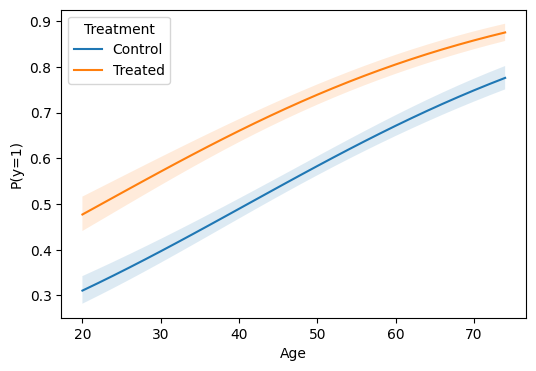

In [9]:
import matplotlib.pyplot as plt

ages = list(range(20, 76, 2))
res = m.predict(atexog={"age": ages, "treated": [0, 1]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
for level, sub in df_plot.groupby("treated"):
    label = "Treated" if level == 1 else "Control"
    ax.plot(sub["age"], sub["estimate"], label=label)
    ax.fill_between(
        sub["age"], sub["ci_lower"], sub["ci_upper"], alpha=0.15
    )
ax.set(xlabel="Age", ylabel="P(y=1)")
ax.legend(title="Treatment")